# Polarization Ray Tracing in Optiland

As of March 2026 (and to the best of my knowledge), Optiland does not provide full support for modeling optical systems containing polarizers or waveplates. What does exist are polarized ray models and Jones matrices. Here I explore workarounds using the concepts that Optiland does provide to implement common polarizing optical elements.

## Approach: Fake a Polarizer as a Coating

The approach that I found relies on an implicit requirement that any child of [`BaseCoatingPolarized`](https://github.com/HarrisonKramer/optiland/blob/ee6fa4cf904c2b6feb5decb4815bc253c208ab33/optiland/coatings.py#L258) must implement a property called `jones`. This property should be of type [`BaseJones`](https://github.com/HarrisonKramer/optiland/blob/ee6fa4cf904c2b6feb5decb4815bc253c208ab33/optiland/jones.py#L25). One example of a concrete implementation is the [`JonesPolarizerH`](https://github.com/HarrisonKramer/optiland/blob/ee6fa4cf904c2b6feb5decb4815bc253c208ab33/optiland/jones.py#L120).

The requirement is implicit because the `BaseCoatingPolarized` base class does not require that its children implement this property. You can see in the implementations of its [`reflect`](https://github.com/HarrisonKramer/optiland/blob/ee6fa4cf904c2b6feb5decb4815bc253c208ab33/optiland/coatings.py#L290) and [`transmit`](https://github.com/HarrisonKramer/optiland/blob/ee6fa4cf904c2b6feb5decb4815bc253c208ab33/optiland/coatings.py#L314) methods, however, that this property **must be defined**; otherwise one will encounter an `AttributeError` when these methods are called.

In [1]:
from optiland.coatings import BaseCoatingPolarized
from optiland.jones import JonesPolarizerH

class LinearPolarizerH(BaseCoatingPolarized):
    def __init__(self) -> None:
        super().__init__()
        self.jones = JonesPolarizerH()

## Coating-Polarizer Implementation

To validate this approach, I create a single dummy surface at the position of the polarizer after the asphere that I created in a previous section and add the custom coating to it.

Number of surfaces: 4
Number of surfaces after adding polarizer: 5


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

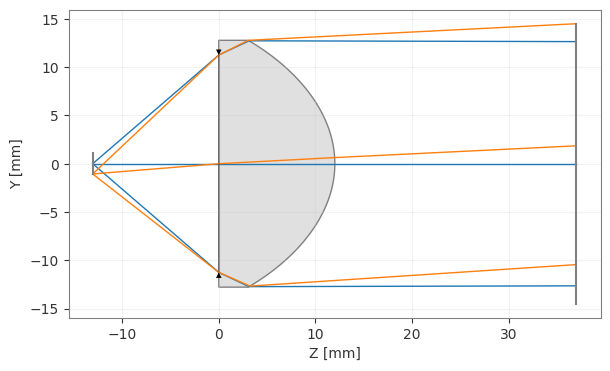

In [2]:
from optiland.rays import PolarizationState, create_polarization

from main import Collimator

collimator = Collimator()
print(f"Number of surfaces: {collimator.surface_group.num_surfaces}")

# The polarization of the Optic must be set before adding surfaces with coatings.
collimator.set_polarization(PolarizationState(is_polarized=False))

# Add a dummy surface at the position of the polarizer after the asphere and add the custom coating to it.
collimator.add_surface(index=3, thickness=0.0, material='air', coating=LinearPolarizerH())
print(f"Number of surfaces after adding polarizer: {collimator.surface_group.num_surfaces}")

collimator.draw(num_rays=3)


The drawback to this approach is that the polarizing dummy surface is not shown. This is because Optiland's rendering system works like the following (`k` is the surface index):

|              Condition               |           Drawn as            |
|--------------------------------------|-------------------------------|
| k == 0 and not infinite              | object surface                |
| k == num_surf - 1                    | image surface                 |
| surf.surface_type == "paraxial"      | paraxial surface              |
| surf.interaction_model.is_reflective | mirror                        |
| n[k] > 1                             | front face of a glass element |
| n[k] == 1 and n[k-1] > 1             | back face of a glass element  |
| interaction_type == "phase"          | phase surface                 |

If the surface does not satisfy any of these conditions, it is not rendered.

In any case, the surface appears to be there after examining the number of surfaces in the optic. Let's now test that the polarizer works.

## Validation

### Horizontal Linear Polarization

The happy path is to verify that the horizontal polarization components are transmitted through the system.

In [3]:
rays = collimator.trace(
    Hx=0.0,
    Hy=0.0,
    num_rays=256,
    wavelength=0.45,
    distribution="uniform",
)

collimator.set_polarization(create_polarization("H"))
rays.update_intensity(create_polarization("H"))
print(f"Mean intensity: {rays.i.mean()}")

Mean intensity: 1.0000000000000002


### Vertical Linear Polarization

In [4]:
rays.update_intensity(create_polarization("V"))
print(f"Mean intensity: {rays.i.mean()}")

Mean intensity: 1.0


Clearly this is wrong, as one of the polarization states should be extinguished. Instead, we see that the "polarizer" does nothing to affect the rays.

## 2nd Workaround: Change the Interaction Model After Surface Creation

I had Claude analyze the Optiland 0.5.9 code. It found that creating the surface without a coating and then setting the interaction model after creation would avoid an erroneous callback that was setting the coating back to a Fresnel air/air interaction. In Claude's own words:

> Look at _update_callback in standard_surface.py:104-108:

```python
def _update_callback(self, caller: Surface) -> None:
    # Handle the changes... If this surface's interaction model has a Fresnel coating, update it:
    if self.coating is not None:
        self.set_fresnel_coating()
```

> This callback fires when `_update_surface_links()` runs after `add_surface` — it calls `set_fresnel_coating()` for any non-None coating, unconditionally overwriting your `LinearPolarizerH` with a `FresnelCoating(air, air)`. (The comment even says "Fresnel coating", but the condition is `coating is not None` — a clear bug vs. the intent.)
>
> For an air-to-air surface, the Fresnel coefficients are both 1.0, so the resulting Jones matrix is effectively identity — explaining why both H and V give 1.0.
>
> Compare this to `material_post.setter` at line 157, which correctly guards the update:

```python
if isinstance(getattr(self.interaction_model, "coating", None), FresnelCoating):
    self.set_fresnel_coating()
```

I can avoid this issue by changing the surface's interaction model **after** the callback has fired.

In [5]:
collimator_2 = Collimator()
print(f"Number of surfaces: {collimator_2.surface_group.num_surfaces}")

collimator_2.set_polarization(PolarizationState(is_polarized=False))

collimator_2.add_surface(index=3, thickness=0.0, material='air')
collimator_2.surface_group.surfaces[3].interaction_model.coating = LinearPolarizerH()
print(f"Number of surfaces after adding polarizer: {collimator_2.surface_group.num_surfaces}")

Number of surfaces: 4
Number of surfaces after adding polarizer: 5


### Horizontal Linear Polarization

In [6]:
rays = collimator_2.trace(
    Hx=0.0,
    Hy=0.0,
    num_rays=256,
    wavelength=0.45,
    distribution="uniform",
)

collimator_2.set_polarization(create_polarization("H"))
rays.update_intensity(create_polarization("H"))
print(f"Mean intensity: {rays.i.mean()}")

Mean intensity: 0.0036415847057852946


### Vertical Linear Polarization

In [7]:
rays.update_intensity(create_polarization("V"))
print(f"Mean intensity: {rays.i.mean()}")

Mean intensity: 0.9963584152942149


We see that `H` polarized light is completely extinguished, whereas nearly all of the `V` polarized components are transmitted through the system. This is a bit surprising as I expected the opposite. I had Claude look into it again, which suggested there is a naming inconsistency within Optiland:

> Now I have enough to give a definitive answer. The root cause is an inconsistent local coordinate system between update (which accumulates the Jones matrices during tracing) and _get_3d_electric_field (which converts the polarization state into a 3D field for update_intensity).
>
> For a ray propagating along z:
> In `update` (polarized_rays.py:124-128), the fallback s-vector is `cross(k, [1,0,0])`:


`s_update = cross([0,0,1], [1,0,0]) = [0, 1, 0]  ← global y`

> In `_get_3d_electric_field` (polarized_rays.py:163-175), the p-vector is `cross(k, [1,0,0])`, and then s is derived from `cross(p, k)`:

```
p_electric = cross([0,0,1], [1,0,0]) = [0, 1, 0]
s_electric = cross([0,1,0], [0,0,1]) = [1, 0, 0]  ← global x
```

> These are swapped. The "s" axis in the Jones matrix (index `[0,0]`) maps to global y in `update`, but `create_polarization("H")` with `Ex=1` maps to global x via `_get_3d_electric_field`.
> 
> You can verify the result by working through the matrix multiplication. The H polarizer's accumulated transformation matrix ends up as:

```
[[0, 0, 0],
 [0, 1, 0],
 [0, 0, 1]]
```

> which transmits E=[0,1,0] (what `create_polarization("V")` generates) and blocks E=[1,0,0] (what `create_polarization("H")`  generates) — exactly backwards from what the names imply.
>
> The fix: Use `JonesPolarizerV` in your coating to block what Optiland calls "V" polarization from `create_polarization`.
>
> This is a naming inconsistency in Optiland between `JonesPolarizerH/V` and `create_polarization("H"/"V")` — they use opposite conventions for which local axis is labeled s vs p.

## Summary

I'm not sure whether Claude's analysis above is correct; I have found that it fails often when performing complex mathematical analyses. The way forward here is to open a ticket into Optiland reporting these issues.

I think the bottom line is that these workarounds are a bit tricky to implement because they are precisely that: workarounds. Optiland does not have first class support for polarizers. Until this happens, I need to proceed carefully and validate the workarounds thoroughly.